<a href="https://colab.research.google.com/github/Sreejit854/Sreejit4940k/blob/main/Indian_Solar__Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas matplotlib geopandas numpy

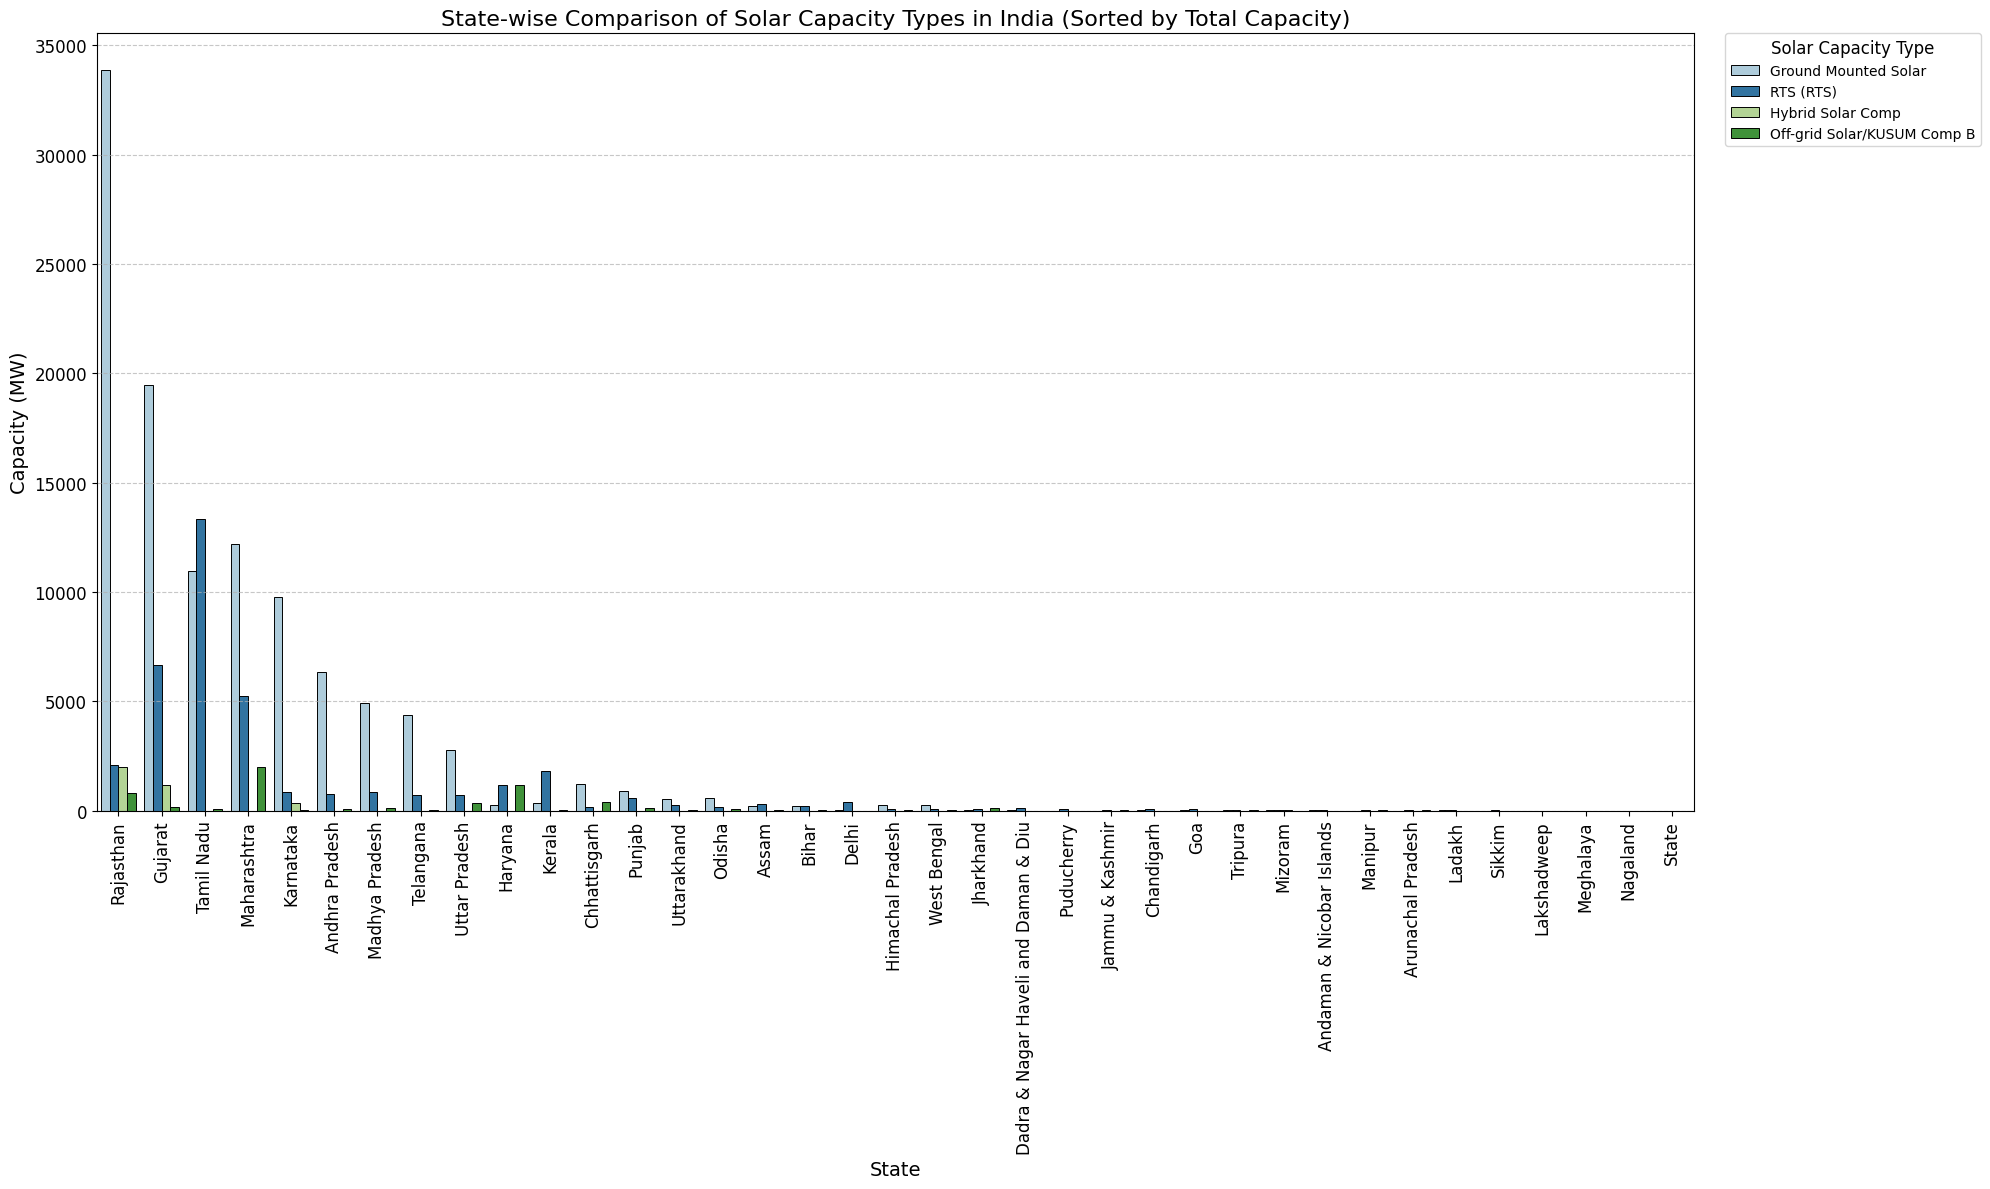

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt # Moved this import to the top

# Calculate total capacity per state to sort them
df_states['Total_State_Capacity'] = df_states[columns_to_plot].sum(axis=1)
# Sort states by their total capacity in descending order
df_states_sorted = df_states.sort_values(by='Total_State_Capacity', ascending=False)

# Melt the DataFrame to long format for easier plotting of multiple categories per state
df_melted = df_states_sorted.melt(id_vars=['State', 'Total_State_Capacity'], value_vars=columns_to_plot, var_name='Capacity_Type', value_name='Capacity_MW')

# Create cleaner labels for the legend
df_melted['Clean_Capacity_Type'] = df_melted['Capacity_Type'].str.replace('_MW', '').str.replace('_', ' ').str.replace('(including PM-Surya Ghar Yojana)', '(RTS)').str.replace('Comp.B', 'Comp B').str.replace('Comp.', 'Comp')

plt.figure(figsize=(20, 12)) # Increased figure size for better visibility
sns.barplot(x='State', y='Capacity_MW', hue='Clean_Capacity_Type', data=df_melted, palette='Paired', edgecolor='black', linewidth=0.7, order=df_states_sorted['State']) # Changed palette to 'Paired'

plt.xlabel('State', fontsize=14)
plt.ylabel('Capacity (MW)', fontsize=14)
plt.title('State-wise Comparison of Solar Capacity Types in India (Sorted by Total Capacity)', fontsize=16)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Solar Capacity Type', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("./figures/statewise_all_capacity_types_comparison_publication_ready.png", dpi=300)
plt.show()

/tmp/ipykernel_7387/4223394823.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Clean_Capacity_Type', y='Total_Capacity_MW', data=df_capacity_total, palette='Paired') # Changed palette to 'Paired'


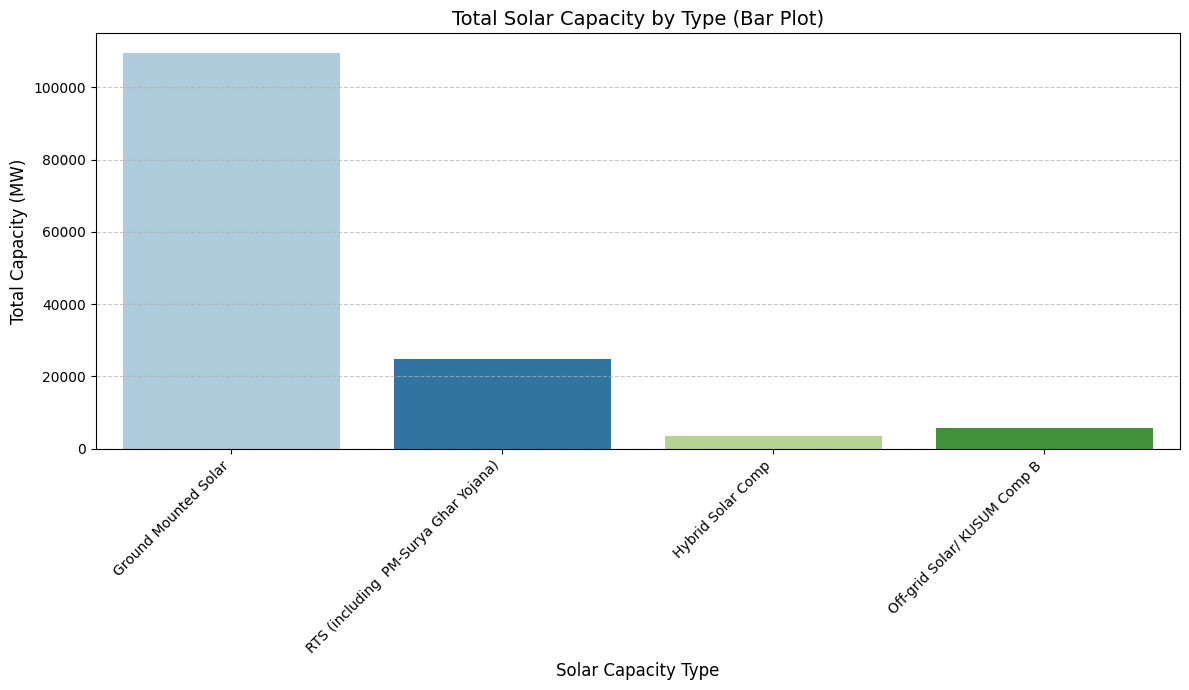

Generated a bar plot for 'Capacity_Type_Total.csv'.


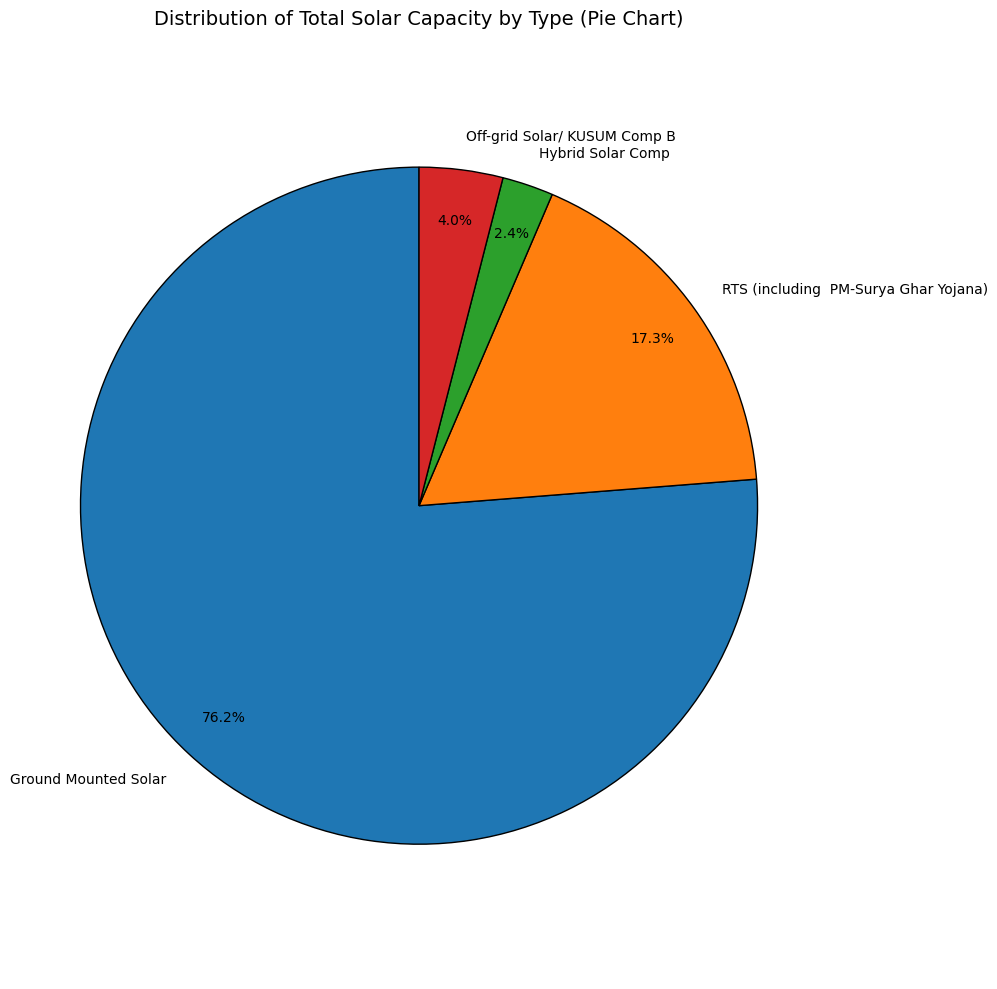

Generated a pie chart for 'Capacity_Type_Total.csv'.


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure the 'figures' directory exists
os.makedirs('./figures', exist_ok=True)

# Load the dataset for plotting
df_capacity_total = pd.read_csv('/content/Capacity_Type_Total.csv')

# Clean up column names
if len(df_capacity_total.columns) == 2:
    df_capacity_total.columns = ['Capacity_Type', 'Total_Capacity_MW']
elif df_capacity_total.shape[1] == 1:
    df_capacity_total = df_capacity_total.iloc[:, 0].str.split(',', expand=True)
    df_capacity_total.columns = ['Capacity_Type', 'Total_Capacity_MW']
else:
    print("Warning: Column names for capacity data not standard. Please verify 'Capacity_Type' and 'Total_Capacity_MW'.")

# Convert capacity to numeric, handling potential errors
df_capacity_total['Total_Capacity_MW'] = pd.to_numeric(df_capacity_total['Total_Capacity_MW'], errors='coerce')

# Drop rows where Total_Capacity_MW is NaN after conversion
df_capacity_total.dropna(subset=['Total_Capacity_MW'], inplace=True)

# Create cleaner labels for plots
df_capacity_total['Clean_Capacity_Type'] = df_capacity_total['Capacity_Type'].astype(str).str.replace('_MW', '').str.replace('_', ' ').str.replace('(including PM-Surya Ghar Yojana)', '(RTS)').str.replace('Comp.B', 'Comp B').str.replace('Comp.', 'Comp')

# --- Generate Bar Plot ---
plt.figure(figsize=(12, 7))
sns.barplot(x='Clean_Capacity_Type', y='Total_Capacity_MW', data=df_capacity_total, palette='Paired') # Changed palette to 'Paired'
plt.xlabel('Solar Capacity Type', fontsize=12)
plt.ylabel('Total Capacity (MW)', fontsize=12)
plt.title('Total Solar Capacity by Type (Bar Plot)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("./figures/capacity_type_total_bar_plot.png", dpi=300)
plt.show()

print("Generated a bar plot for 'Capacity_Type_Total.csv'.")

# --- Generate Pie Chart ---
plt.figure(figsize=(10, 10))
plt.pie(df_capacity_total['Total_Capacity_MW'],
        labels=df_capacity_total['Clean_Capacity_Type'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'black'},
        pctdistance=0.85,
        labeldistance=1.1)

plt.title('Distribution of Total Solar Capacity by Type (Pie Chart)', fontsize=14)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.savefig("./figures/capacity_type_total_pie_chart.png", dpi=300)
plt.show()

print("Generated a pie chart for 'Capacity_Type_Total.csv'.")

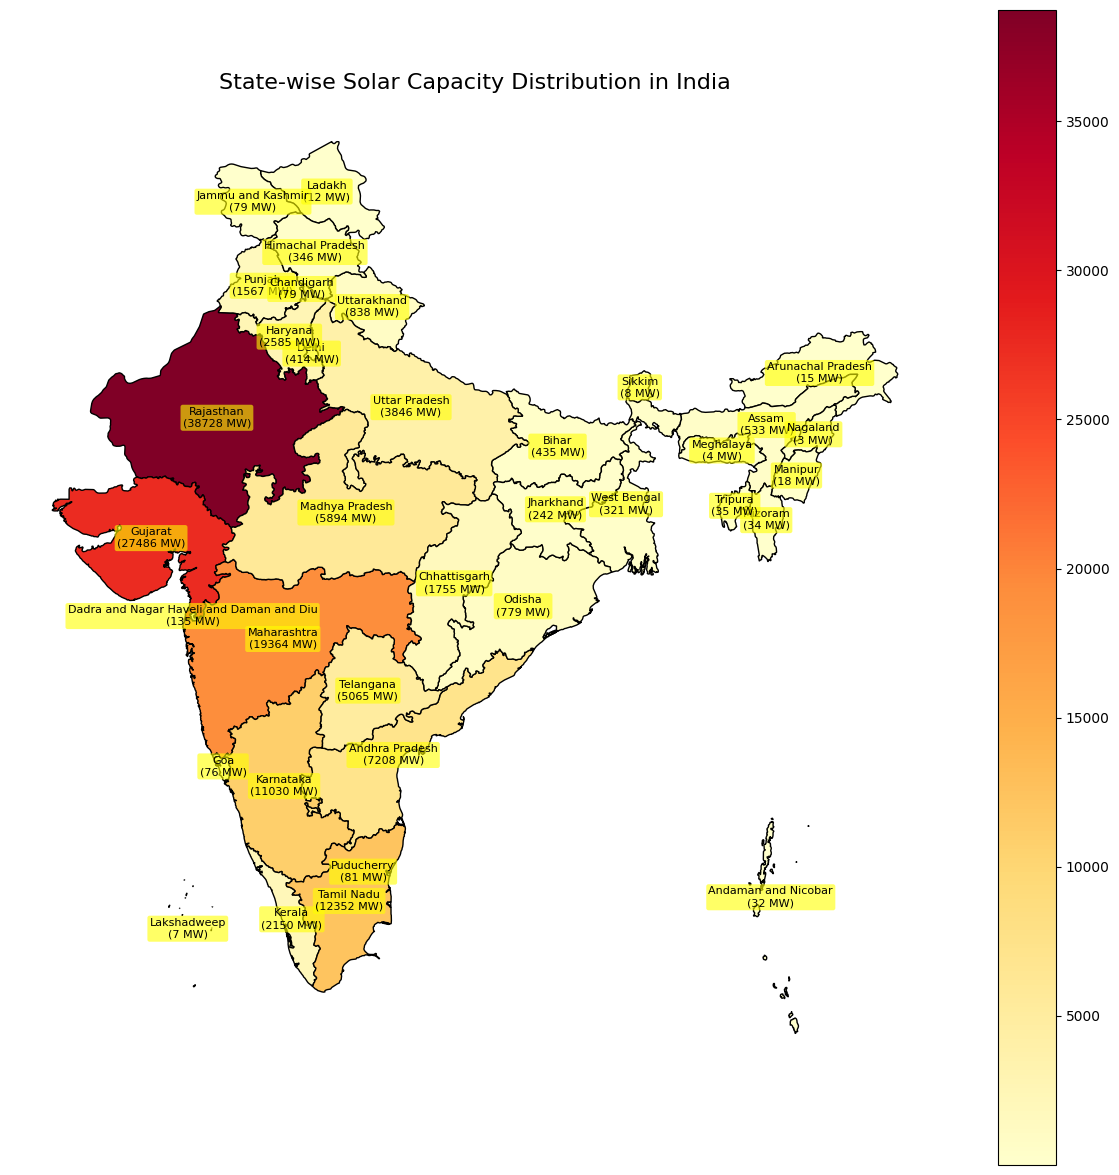

In [47]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os

india = gpd.read_file("/content/india_states.shp")
india = india[india['admin'] == 'India']

data = pd.read_csv("/content/state_solar_capacity.csv")
# Manually split the combined 'State,Capacity_MW' column
data[['State', 'Capacity_MW']] = data['State,Capacity_MW'].str.split(',', expand=True)
data['Capacity_MW'] = pd.to_numeric(data['Capacity_MW']) # Convert to numeric

india = india.merge(data, left_on="name", right_on="State", how="left")

fig, ax = plt.subplots(figsize=(15,15)) # Increased figure size for better readability

india.plot(column='Capacity_MW',
           cmap='YlOrRd',
           legend=True,
           edgecolor='black',
           ax=ax,
           missing_kwds={
               "color": "lightgrey",
               "edgecolor": "black",
               "hatch": "///",
               "label": "No Data",
           }) # Highlight states with no data

# Add annotations for State Name and Capacity_MW, including 'No Data' for missing values
# Adjusted xytext to offset the labels and added more visual clarity
for idx, row in india.iterrows():
    capacity_text = f"{row['Capacity_MW']:.0f} MW" if not pd.isna(row['Capacity_MW']) else "No Data"
    ax.annotate(text=f"{row['name']}\n({capacity_text})",
                xy=row.geometry.centroid.coords[0], # Anchor point at the centroid
                xytext=(0, 0), textcoords="offset points", # Offset from anchor point
                fontsize=8, color='black', ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.2", fc='yellow', alpha=0.6, ec='none')) # Add a background box

plt.title("State-wise Solar Capacity Distribution in India", fontsize=16)
plt.axis('off')

# Create the 'figures' directory if it doesn't exist and save to the correct path
os.makedirs('./figures', exist_ok=True)
plt.savefig("./figures/map_final.png", dpi=300)
plt.show()